In [137]:
import sys
import pandas as pd
import numpy as np
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import Trainer, TrainingArguments
from transformers import PatchTSTConfig, PatchTSTForPrediction

sys.path.append('../src')

from dataset import resumo_periodo
from models.har import HarModel
from config import DF_VOL_FILE

# ==================== SETUP INICIAL ====================
# Detecta GPU disponível (mais rápido) ou usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Precision: bfloat16 é mais rápido em GPU modernas (Ampere+), float32 é universal
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

dados = pd.read_csv(DF_VOL_FILE, parse_dates=['date'])

Device: cpu | Precision: torch.float32


In [138]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'date'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
FEATURES = ["Vol_lag_1", "Vol_week_mean", "Vol_month_mean"]
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 512         # Janela histórica: x dias passados
FORECAST_HORIZON = 96        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 1            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 4             # Workers para data loading (0 em Windows)
EPOCHS = 30                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 1e-3        # Taxa de aprendizado

# Processo de treinamento

## Preparação dados

In [139]:
infos_total = resumo_periodo(dados, TIMESTAMP_COLUMN)

📅 Dataset
   Início : 01/12/2017
   Fim    : 01/12/2024
   Duração: 7 anos e 2 dias (2557 dias no total)



In [140]:
from tsfm_public.toolkit.util import select_by_index

dados.sort_values(by=TIMESTAMP_COLUMN, inplace=True)

n = len(dados)
train_end = int(n * TRAIN_FRAC)
valid_end = int(n * (TRAIN_FRAC + VALID_FRAC))

train_df = select_by_index(dados, start_index=None, end_index=train_end)
valid_df = select_by_index(dados, start_index=train_end - CONTEXT_LENGTH, end_index=valid_end)
test_df = select_by_index(dados, start_index=valid_end - CONTEXT_LENGTH, end_index=None)

In [141]:
def first_prediction_date(df, context_length, timestamp_col):
    return df[timestamp_col].iloc[context_length]

print("Primeira previsão treino:", first_prediction_date(train_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))
print("Primeira previsão validação:", first_prediction_date(valid_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))
print("Primeira previsão teste:", first_prediction_date(test_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))

Primeira previsão treino: 2019-04-27 00:00:00
Primeira previsão validação: 2022-10-26 00:00:00
Primeira previsão teste: 2023-07-09 00:00:00


In [142]:
info_train = resumo_periodo(train_df, TIMESTAMP_COLUMN)
info_valid = resumo_periodo(valid_df, TIMESTAMP_COLUMN)
info_test = resumo_periodo(test_df, TIMESTAMP_COLUMN)

📅 Dataset
   Início : 01/12/2017
   Fim    : 25/10/2022
   Duração: 4 anos e 329 dias (1789 dias no total)

📅 Dataset
   Início : 01/06/2021
   Fim    : 08/07/2023
   Duração: 2 anos e 37 dias (767 dias no total)

📅 Dataset
   Início : 12/02/2022
   Fim    : 01/12/2024
   Duração: 2 anos e 293 dias (1023 dias no total)



## Normalização Dados

In [143]:
# ==================== PRÉ-PROCESSAMENTO: NORMALIZAÇÃO ====================
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset

# Normaliza dados: subtrai média, divide por std
# Essencial para modelos deep learning (converge melhor)
tsp = TimeSeriesPreprocessor(
    timestamp_column=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    feature_columns=FEATURES,
    id_columns=ID_COLUMNS,
    scaling='std'  # standardscaler: (x - mean)/std
)
tsp.train(train_df)  # Aprende mean/std no treino

def make_ds(df):
    """Cria dataset com janelas deslizantes"""
    return ForecastDFDataset(
        tsp.preprocess(df),  # Normaliza usando parâmetros do treino
        id_columns=ID_COLUMNS,
        target_columns=TARGET_COLUMN,
        context_length=CONTEXT_LENGTH,      # Quantos dias de histórico usar
        prediction_length=FORECAST_HORIZON, # Quantos dias prever
    )

train_ds, valid_ds, test_ds = map(make_ds, [train_df, valid_df, test_df])
print(f"Treino: {len(train_ds)} amostras | Val: {len(valid_ds)} | Teste: {len(test_ds)}")

Treino: 1183 amostras | Val: 161 | Teste: 417


## Carregando Modelo PatchTST pré-treinado

In [144]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 614,496


## Métricas de Avaliação

In [145]:
# ==================== MÉTRICAS DE AVALIAÇÃO ====================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(eval_pred):
    """Calcula MAE, MSE, RMSE, MAPE denormalizando as previsões"""
    pred, labels = eval_pred
    pred = pred[0] if isinstance(pred, tuple) else pred
    C = len(TARGET_COLUMN)

    # Recupera scaler original (inverte normalização)
    scaler = next(iter(tsp.target_scaler_dict.values()))
    pred = scaler.inverse_transform(pred.reshape(-1, C)).reshape(pred.shape)
    labels = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    # Achata arrays para cálculo de métricas
    # pred = pred.reshape(-1)
    # labels = labels.reshape(-1)

    pred = pred[:, 0, 0]
    labels = labels[:, 0, 0]

    mae = mean_absolute_error(labels, pred)
    mse = mean_squared_error(labels, pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((labels - pred) / (np.abs(labels) + 1e-9))) * 100
    
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [146]:
def evaluate_and_visualize(model, test_dataset, tsp, model_name="Modelo"):
    """Avalia modelo no dataset de teste e visualiza previsões."""
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            label_names=["future_values"]
        )
    )

    # Predições
    outputs = trainer.predict(test_dataset)

    predictions = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
    labels = outputs.label_ids

    C = len(TARGET_COLUMN) + len(FEATURES)
    scaler = next(iter(tsp.target_scaler_dict.values()))

    # Desnormaliza
    pred_original = scaler.inverse_transform(predictions.reshape(-1, C)).reshape(predictions.shape)

    labels_original = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    # Pega apenas o primeiro passo do horizonte
    pred_1step = pred_original[:, 0, 0]
    label_1step = labels_original[:, 0, 0]

    test_dates = test_df[TIMESTAMP_COLUMN].values
    forecast_dates = test_dates[CONTEXT_LENGTH : CONTEXT_LENGTH + len(pred_1step)]

    metrics_1step = {
        'MSE': mean_squared_error(label_1step, pred_1step),
        'MAE': mean_absolute_error(label_1step, pred_1step),
        'RMSE': np.sqrt(mean_squared_error(label_1step, pred_1step)),
        'MAPE': np.mean(
            np.abs((label_1step - pred_1step) / (np.abs(label_1step) + 1e-9))
        ) * 100
    }

    print(f"\n=== AVALIAÇÃO {model_name} ===\n")
    for k, v in metrics_1step.items():
        print(f"  {k}: {v:.6e}")

    plt.figure(figsize=(12,6))
    plt.plot(forecast_dates, label_1step, label="True", color="blue")
    plt.plot(forecast_dates, pred_1step, label="Predicted", linestyle="--", color="red")
    plt.title(f"{model_name} – True vs Predicted Volatility")
    plt.legend()
    plt.grid()
    plt.show()

    return forecast_dates, metrics_1step

## Treinando o modelo

In [147]:
trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="metric_temp",
        label_names=["future_values"]
    )
)

# Predições
outputs = trainer.predict(test_ds)

# Resultados

## Exploração de resultados

In [148]:
preds = outputs.predictions  # Formato: (num_samples, num_janelas, forecast_horizon)
len(preds), len(preds[0]), len(preds[0][0]), len(preds[0][0][0])

(3, 417, 96, 1)

In [149]:
predictions = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
labels = outputs.label_ids

In [150]:
predictions.shape, labels.shape, scaler.mean_.shape

((417, 96, 1), (417, 96, 1), (4,))

In [151]:
C = len(TARGET_COLUMN)
scaler = next(iter(tsp.target_scaler_dict.values()))

# Desnormaliza
pred_original = scaler.inverse_transform(predictions.reshape(-1, 4)).reshape(predictions.shape)

labels_original = scaler.inverse_transform(labels.reshape(-1, 4)).reshape(labels.shape)

# Pega apenas o primeiro passo do horizonte
pred_1step = pred_original[:, 0, 0]
label_1step = labels_original[:, 0, 0]

In [152]:
print(tsp.target_columns)

['Vol', 'Vol_lag_1', 'Vol_week_mean', 'Vol_month_mean']


In [153]:
scaler.mean_, scaler.scale_

(array([0.00214353, 0.00215174, 0.00216477, 0.00220997]),
 array([0.00509649, 0.00510618, 0.00364855, 0.00275111]))

## Comparação HAR vs PatchTST - Métricas e Gráfico

In [154]:
test_dates = test_df[TIMESTAMP_COLUMN].values
forecast_dates = test_dates[CONTEXT_LENGTH : CONTEXT_LENGTH + len(pred_1step)]

In [155]:
test_df = test_df[test_df[TIMESTAMP_COLUMN].isin(forecast_dates)]

In [156]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET_COLUMN].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET_COLUMN].values
test_dates = test_df[TIMESTAMP_COLUMN].values


=== AVALIAÇÃO FINAL - LinearRegression (HAR) ===
TREINO:
  MSE: 1.869489e-05
  MAE: 1.370943e-03
  RMSE: 4.323759e-03
  MAPE: 1.144134e+02

TESTE:
  MSE: 1.101758e-06
  MAE: 5.924590e-04
  RMSE: 1.049647e-03
  MAPE: 2.541495e+02

Visualizando previsões no conjunto de teste...


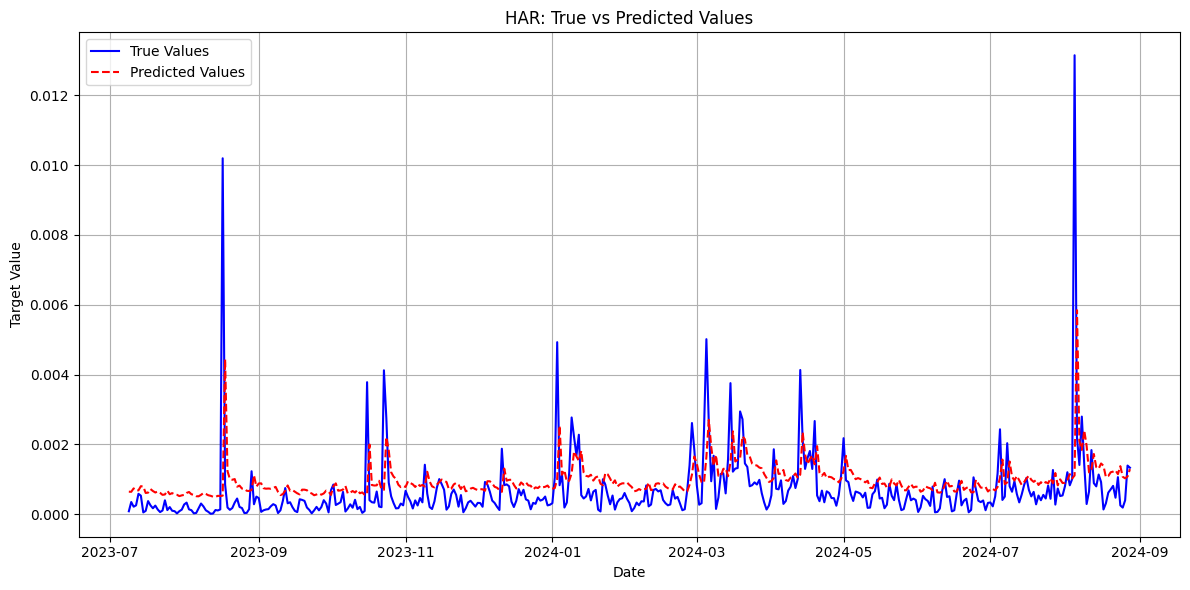

In [157]:
har = HarModel()
har.train(X_train, y_train)

y_pred_train = har.predict(X_train)
y_pred_test  = har.predict(X_test)

har.evaluate_and_visualize(
    y_train, y_pred_train,
    y_test, y_pred_test,
    test_dates=test_dates
)


=== AVALIAÇÃO Transformer Zero Shot ===

  MSE: 1.142447e-06
  MAE: 6.195744e-04
  RMSE: 1.068853e-03
  MAPE: 3.127089e+02


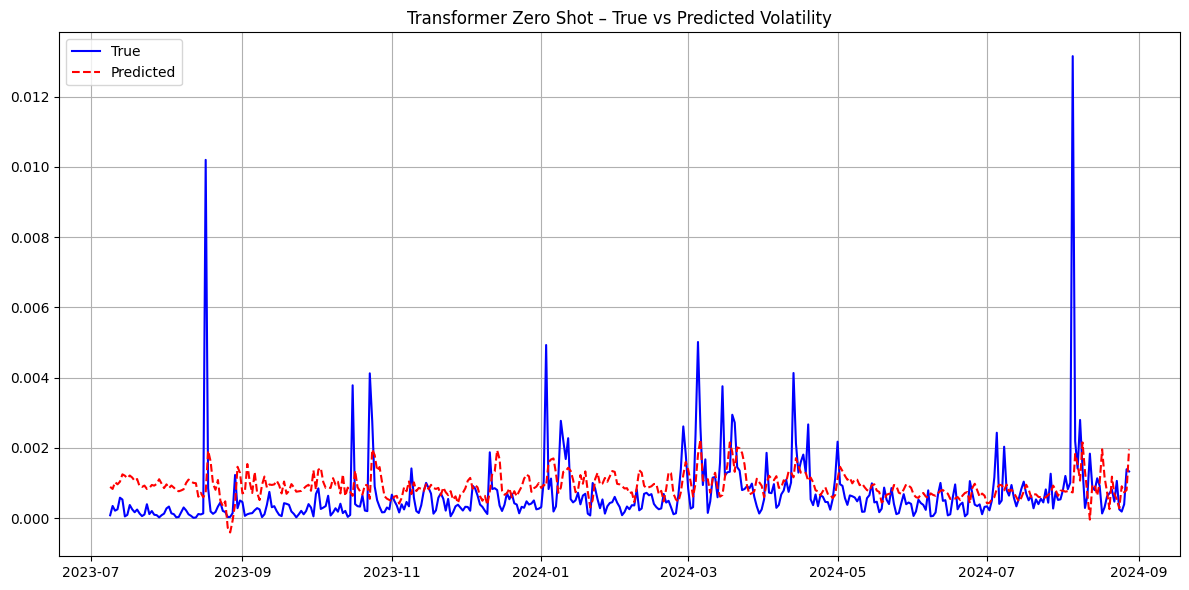

In [158]:
import matplotlib.pyplot as plt

metrics_1step = {
    'MSE': mean_squared_error(label_1step, pred_1step),
    'MAE': mean_absolute_error(label_1step, pred_1step),
    'RMSE': np.sqrt(mean_squared_error(label_1step, pred_1step)),
    'MAPE': np.mean(
        np.abs((label_1step - pred_1step) / (np.abs(label_1step) + 1e-9))
    ) * 100
}

print(f"\n=== AVALIAÇÃO Transformer Zero Shot ===\n")
for k, v in metrics_1step.items():
    print(f"  {k}: {v:.6e}")

plt.figure(figsize=(12,6))
plt.plot(forecast_dates, label_1step, label="True", color="blue")
plt.plot(forecast_dates, pred_1step, label="Predicted", linestyle="--", color="red")
plt.title(f"Transformer Zero Shot – True vs Predicted Volatility")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()